In [3]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
def results_to_df(results_list, dataset, sampling_method, rec_method):
    res = []
    for config in results_list:
        if sampling_method.endswith("_dp"):
            e = config["e"]
        else:
            e = np.inf
        b = config["b"]
        test_mae = config["test_mae"]
        res.append((dataset, rec_method, sampling_method, e, b, test_mae))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "recsys", "sampling", "e", "b", "test_mae"])

Text(0, 0.5, 'MAE')

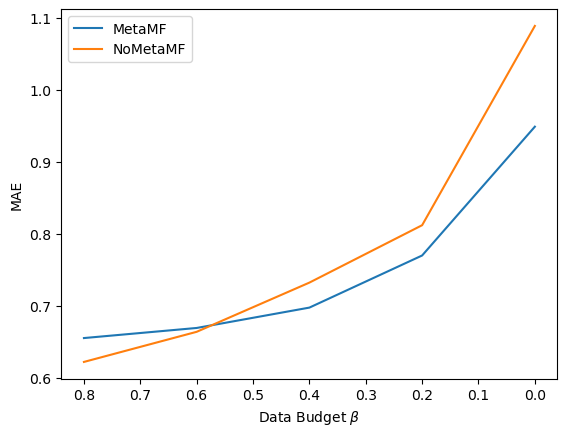

In [44]:
with open(PATH + "MetaMF.random_del", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_df = results_to_df(meta_results, dataset="ml1m", sampling_method="random_del", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_del", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_df = results_to_df(nometa_results, dataset="ml1m", sampling_method="random_del", rec_method="NoMetaMF")

results_df = pd.concat([meta_results_df, nometa_results_df]).reset_index(drop=True)


meta = results_df[(results_df["recsys"] == "MetaMF")]
plt.plot(meta["b"],  meta["test_mae"], label="MetaMF")

nometa = results_df[(results_df["recsys"] == "NoMetaMF")]
plt.plot(nometa["b"],  nometa["test_mae"], label="NoMetaMF")

plt.gca().invert_xaxis()

plt.legend()
plt.xlabel(r"Data Budget $\beta$")
plt.ylabel("MAE")

# RQ1: Does Meta Learning improve the accuracy-privacy trade-off? (MetaMF vs. NoMetaMF)

In [27]:
DATASET = "ml1m"
PATH = DATASET + "/"
with open(PATH + "MetaMF.random_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_df = results_to_df(meta_results, dataset="ml1m", sampling_method="random_dp", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_df = results_to_df(nometa_results, dataset="ml1m", sampling_method="random_dp", rec_method="NoMetaMF")
results_df = pd.concat([meta_results_df, nometa_results_df]).reset_index(drop=True)
results_df.head()

,dataset,recsys,sampling,e,b,test_mae
0,ml1m,MetaMF,random_dp,3.0,0.0,0.692591
1,ml1m,MetaMF,random_dp,3.0,0.2,0.692166
2,ml1m,MetaMF,random_dp,3.0,0.4,0.691901
3,ml1m,MetaMF,random_dp,3.0,0.6,0.690709
4,ml1m,MetaMF,random_dp,3.0,0.8,0.683734


Text(0, 0.5, 'MAE')

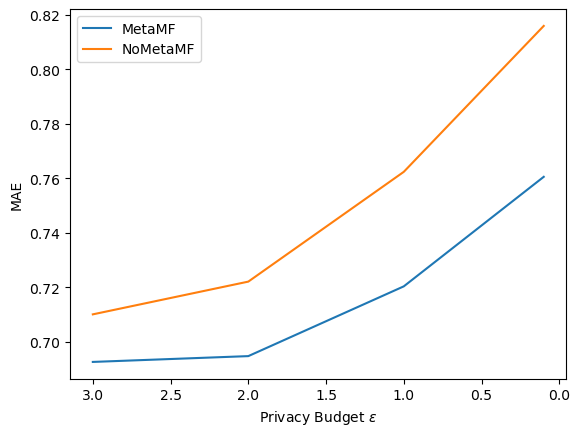

In [28]:
meta = results_df[(results_df["recsys"] == "MetaMF") & (results_df["b"] == 0)]
plt.plot(meta["e"], meta["test_mae"], label="MetaMF")

nometa = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["b"] == 0)]
plt.plot(nometa["e"], nometa["test_mae"], label="NoMetaMF")

plt.gca().invert_xaxis()

plt.legend()
plt.xlabel(r"Privacy Budget $\varepsilon$")
plt.ylabel("MAE")

Text(0, 0.5, '$\\Delta$MAE in $\\%$')

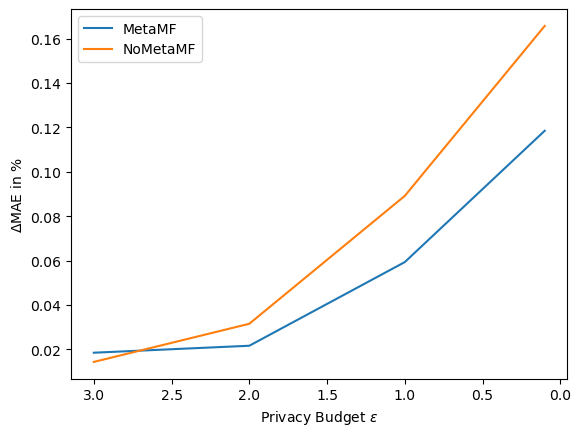

In [29]:
meta = results_df[(results_df["recsys"] == "MetaMF") & (results_df["b"] == 0)]
plt.plot(meta["e"], (meta["test_mae"] - 0.68) / 0.68, label="MetaMF")

nometa = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["b"] == 0)]
plt.plot(nometa["e"], (nometa["test_mae"] - 0.7) / 0.7, label="NoMetaMF")

plt.gca().invert_xaxis()

plt.legend()
plt.xlabel(r"Privacy Budget $\varepsilon$")
plt.ylabel(r"$\Delta$MAE in $\%$")

# RQ2: How can sampling improve the trade-off further?

In [47]:
DATASET = "ml1m"
PATH = DATASET + "/"
with open(PATH + "MetaMF.random_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_random_dp_df = results_to_df(meta_results, dataset="ml1m", sampling_method="random_dp", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_random_dp_df = results_to_df(nometa_results, dataset="ml1m", sampling_method="random_dp", rec_method="NoMetaMF")
with open(PATH + "MetaMF.ister_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_ister_dp_df = results_to_df(meta_results, dataset="ml1m", sampling_method="ister_dp", rec_method="MetaMF")
with open(PATH + "NoMetaMF.ister_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_ister_dp_df = results_to_df(nometa_results, dataset="ml1m", sampling_method="ister_dp", rec_method="NoMetaMF")

dp_results_df = pd.concat([meta_results_random_dp_df, nometa_results_random_dp_df, meta_results_ister_dp_df, nometa_results_ister_dp_df]).reset_index(drop=True)
with open(PATH + "MetaMF.random_del", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_random_del_df = results_to_df(meta_results, dataset="ml1m", sampling_method="random_del", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_del", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_random_del_df = results_to_df(nometa_results, dataset="ml1m", sampling_method="random_del", rec_method="NoMetaMF")
"""with open(PATH + "MetaMF.ister_del", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_ister_del_df = results_to_df(meta_results, dataset="ml1m", sampling_method="ister_del", rec_method="MetaMF")
with open(PATH + "NoMetaMF.ister_del", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_ister_del_df = results_to_df(nometa_results, dataset="ml1m", sampling_method="ister_del", rec_method="NoMetaMF")
del_results_df = pd.concat([meta_results_random_del_df, nometa_results_random_del_df, meta_results_ister_del_df, nometa_results_ister_del_df]).reset_index(drop=True)
"""
del_results_df = pd.concat([meta_results_random_del_df, nometa_results_random_del_df])

results_df = pd.concat([dp_results_df, del_results_df])
results_df

,dataset,recsys,sampling,e,b,test_mae
0,ml1m,MetaMF,random_dp,3.0,0.0,0.692591
1,ml1m,MetaMF,random_dp,3.0,0.2,0.692166
2,ml1m,MetaMF,random_dp,3.0,0.4,0.691901
3,ml1m,MetaMF,random_dp,3.0,0.6,0.690709
4,ml1m,MetaMF,random_dp,3.0,0.8,0.683734
...,...,...,...,...,...,...
0,ml1m,NoMetaMF,random_del,inf,0.0,1.088576
1,ml1m,NoMetaMF,random_del,inf,0.2,0.812028
2,ml1m,NoMetaMF,random_del,inf,0.4,0.732374
3,ml1m,NoMetaMF,random_del,inf,0.6,0.664092


Text(0, 0.5, 'MAE')

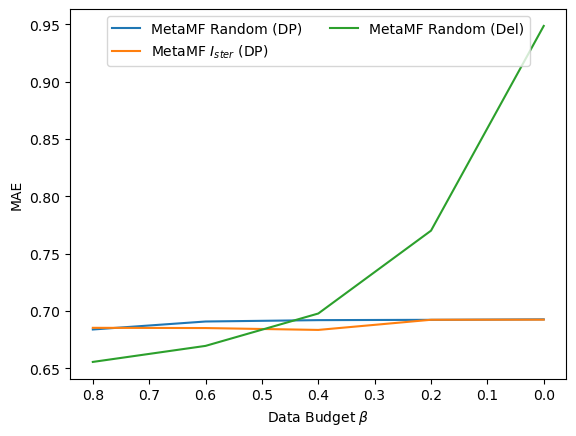

In [53]:
e = 3

meta_random = results_df[(results_df["recsys"] == "MetaMF") & (results_df["sampling"] == "random_dp") & (results_df["e"] == e)]
meta_ister = results_df[(results_df["recsys"] == "MetaMF") & (results_df["sampling"] == "ister_dp") & (results_df["e"] == e)]
plt.plot(meta_random["b"], meta_random["test_mae"], label="MetaMF Random (DP)", c="C0")
plt.plot(meta_ister["b"], meta_ister["test_mae"], label=r"MetaMF $I_{ster}$ (DP)", c="C1")

#nometa_random = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["sampling"] == "random_dp") & (results_df["e"] == e)]
#nometa_ister = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["sampling"] == "ister_dp") & (results_df["e"] == e)]
#plt.plot(nometa_random["b"], nometa_random["test_mae"], label="NoMetaMF Random (DP)", c="C0", linestyle="dashed")
#plt.plot(nometa_ister["b"], nometa_ister["test_mae"], label=r"NoMetaMF $I_{ster}$ (DP)", c="C1", linestyle="dashed")

meta_random = results_df[(results_df["recsys"] == "MetaMF") & (results_df["sampling"] == "random_del")]
#meta_ister = results_df[(results_df["recsys"] == "MetaMF") & (results_df["sampling"] == "ister_del")]
plt.plot(meta_random["b"], meta_random["test_mae"], label="MetaMF Random (Del)", c="C2")
#plt.plot(meta_ister["b"], meta_ister["test_mae"], label=r"MetaMF $I_{ster}$ (Del)", c="C3")

#nometa_random = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["sampling"] == "random_del")]
#nometa_ister = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["sampling"] == "ister_del")]
#plt.plot(nometa_random["b"], nometa_random["test_mae"], label="NoMetaMF Random (Del)", c="C2", linestyle="dashed")
#plt.plot(nometa_ister["b"], nometa_ister["test_mae"], label=r"NoMetaMF $I_{ster}$ (Del)", c="C3", linestyle="dashed")


plt.gca().invert_xaxis()

plt.legend(ncols=2, loc="upper center")
plt.xlabel(r"Data Budget $\beta$")
plt.ylabel("MAE")